# 🖼️ AI Agent Hub — Agente de Visão (vision_pipeline.ipynb)
Este notebook representa o módulo de **Visão Computacional** do projeto AI Agent Hub.

🎯 Função atual:
- Processar imagens e estimar quantidades de objetos (porcas/parafusos);
- Gerar um pequeno relatório visual.

💡 Este notebook serviu como base do MVP original e agora faz parte do sistema modular,
onde atuará como o **Agente de Visão** conectado ao pipeline principal.


# 🧰 Imports & utilidades
Nesta célula:
- Importamos bibliotecas (cv2, numpy, matplotlib, json, datetime).
- Definimos utilitários de exibição de imagem e criação de diretórios de logs.
- Mantemos a execução compatível com CPU (sem dependências de GPU).



In [1]:
import os, json, math, uuid, time
from datetime import datetime
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Configurações básicas
os.makedirs("data/images", exist_ok=True)
os.makedirs("data/logs", exist_ok=True)
os.makedirs("data/models", exist_ok=True)

def show_image_bgr(img_bgr, title="Imagem (BGR→RGB)"):
    """Exibe imagem BGR (OpenCV) convertendo para RGB no matplotlib."""
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6,6))
    plt.title(title)
    plt.axis("off")
    plt.imshow(img_rgb)
    plt.show()

def save_log(payload: dict, prefix: str="run"):
    """Salva dicionário de resultados em JSON com timestamp."""
    ts = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")
    rid = str(uuid.uuid4())[:8]
    path = f"data/logs/{prefix}_{ts}_{rid}.json"
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)
    return path


# 🖼️ Entrada de imagem (upload ou exemplo)
Nesta célula você pode:
- **Fazer upload** de uma imagem do seu computador, ou
- Usar uma **URL de exemplo** para testar rapidamente.

Saída: imagem carregada em `img_bgr`.



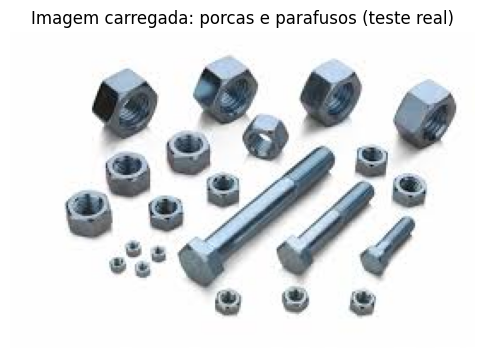

📁 Imagem salva em: data/images/sample_bolts_nuts.jpg
📏 Dimensões: (185, 272, 3)


In [6]:
from pathlib import Path
import urllib.request
import cv2

# ✅ Link da imagem real de porcas e parafusos
sample_url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSjLmAti4Lxli_wLYukUlwGsE3Zwkr4TKe3nQ&s"

# Caminho local para salvar a imagem
image_path = "data/images/sample_bolts_nuts.jpg"

# Cria pasta se necessário
Path("data/images").mkdir(parents=True, exist_ok=True)

try:
    # Faz o download e salva localmente
    urllib.request.urlretrieve(sample_url, image_path)
    img_bgr = cv2.imread(image_path)

    if img_bgr is None:
        raise RuntimeError("⚠️ A imagem foi baixada, mas não pôde ser lida pelo OpenCV.")

    # Exibe imagem carregada
    show_image_bgr(img_bgr, title="Imagem carregada: porcas e parafusos (teste real)")
    print(f"📁 Imagem salva em: {image_path}")
    print(f"📏 Dimensões: {img_bgr.shape}")
except Exception as e:
    print("❌ Erro ao carregar a imagem:", e)
    print("💡 Dica: tente fazer upload manual definindo USE_UPLOAD=True.")


# 🔍 Agente de Visão (OpenCV)
Objetivo: transformar a imagem em uma representação binária limpa e usar **contornos** para estimar
quantidades de objetos de dois tipos genéricos, como se fossem:
- **'porca'** (formas mais circulares ou com furo),
- **'parafuso'** (formas mais alongadas).

⚠️ É uma **heurística simples** (MVP). Em seguida podemos evoluir para:
- CNN pré-treinada (ex.: MobileNetV2) para classificação,
- Segmentação/Detecção mais robusta,
- Regras específicas para seu dataset.

Saídas:
- `vision_result` (dict com contagens e métricas).
- Imagens intermediárias para inspeção (threshold/máscara/contornos).


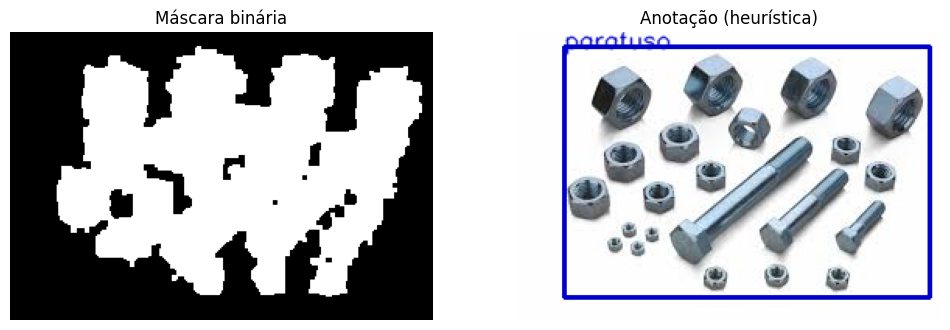

Resultado (visão): {
  "objetos": {
    "porca": 0,
    "parafuso": 1
  },
  "total": 1,
  "qualidade": "boa",
  "metrica": {
    "n_contornos": 1,
    "area_media": 24542.0
  }
}


In [11]:
def vision_agent_count(img_bgr):
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    # equalização leve para destacar contrastes
    img_eq = cv2.equalizeHist(img_gray)
    # Suaviza reflexos e ruídos finos
    img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

    # Equaliza contraste global (melhora bordas metálicas)
    img_eq = cv2.equalizeHist(img_blur)

    # binarização (Otsu)
    _, th = cv2.threshold(img_eq, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Normaliza "fundo claro" vs "fundo escuro": garante objetos como 255 (branco)
    # Decide automaticamente invertendo se necessário (mais branco que preto?)
    if np.mean(th) > 127:
        th = cv2.bitwise_not(th)

    # Remoção de ruído (morfologia)
    kernel = np.ones((3,3), np.uint8)
    th_clean = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel, iterations=1)
    th_clean = cv2.morphologyEx(th_clean, cv2.MORPH_CLOSE, kernel, iterations=1)

    # Contornos
    contours, _ = cv2.findContours(th_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    cnt_porcas = 0
    cnt_parafusos = 0
    areas = []
    annotated = img_bgr.copy()

    for c in contours:
        area = cv2.contourArea(c)
        if area < 80:  # filtra ruído muito pequeno
            continue
        areas.append(area)
        x,y,w,h = cv2.boundingRect(c)

        # Métricas geométricas simples
        aspect = w / (h + 1e-6)
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)
        hull = cv2.convexHull(c)
        hull_area = cv2.contourArea(hull) + 1e-6
        solidity = area / hull_area

        # Circularidade: 4πA / P^2 (próximo de 1 = círculo)
        circularity = (4 * math.pi * area) / (peri*peri + 1e-6)

        # Heurística:
        # - "porca" ~ formato mais circular/convexo (ou anel).
        # - "parafuso" ~ formato mais alongado (aspect ratio distante de 1) e menos circular.
        is_circularish = circularity > 0.6 and 0.6 < solidity <= 1.0
        is_elongated   = (aspect > 1.6 or aspect < 0.62) and circularity < 0.55

        label = None
        if is_circularish and not is_elongated:
            label = "porca"
            cnt_porcas += 1
            color = (0, 200, 0)
        elif is_elongated:
            label = "parafuso"
            cnt_parafusos += 1
            color = (200, 0, 0)
        else:
            # se não classificar claramente, escolha a categoria "mais próxima"
            label = "porca" if circularity >= 0.55 else "parafuso"
            if label == "porca":
                cnt_porcas += 1
                color = (0, 200, 0)
            else:
                cnt_parafusos += 1
                color = (200, 0, 0)

        cv2.rectangle(annotated, (x,y), (x+w, y+h), color, 2)
        cv2.putText(annotated, label, (x, max(10, y-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)

    total = cnt_porcas + cnt_parafusos
    quality = "boa" if total > 0 else "indefinida"

    result = {
        "objetos": {"porca": int(cnt_porcas), "parafuso": int(cnt_parafusos)},
        "total": int(total),
        "qualidade": quality,
        "metrica": {
            "n_contornos": int(len(contours)),
            "area_media": float(np.mean(areas)) if areas else 0.0,
        }
    }

    return result, th_clean, annotated

vision_result, th_img, annotated = vision_agent_count(img_bgr)

# Visualização rápida
plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.title("Máscara binária"); plt.axis("off"); plt.imshow(th_img, cmap="gray")
plt.subplot(1,2,2); plt.title("Anotação (heurística)"); plt.axis("off")
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.show()

print("Resultado (visão):", json.dumps(vision_result, ensure_ascii=False, indent=2))


# 📝 Agente de Linguagem (NLG simples)
Gera uma **descrição textual** a partir do dicionário produzido pelo agente de visão.
Nesta versão, usamos **template baseado em regras** (sem modelos pesados),
para manter o MVP leve e 100% CPU.

Saída:
- `report_text`: texto curto e objetivo com a contagem e uma conclusão inicial.


In [12]:
def nlp_agent_describe(vision_dict: dict, idioma: str = "pt"):
    objs = vision_dict.get("objetos", {})
    n_porcas = int(objs.get("porca", 0))
    n_parafusos = int(objs.get("parafuso", 0))
    total = int(vision_dict.get("total", n_porcas + n_parafusos))
    qualidade = vision_dict.get("qualidade", "indefinida")

    if idioma == "pt":
        base = f"A imagem contém {n_parafusos} parafuso(s) e {n_porcas} porca(s), totalizando {total} item(ns)."
        if qualidade == "boa" and total > 0:
            concl = "O lote aparenta estar consistente visualmente."
        elif total == 0:
            concl = "Não foram detectados itens com confiança suficiente."
        else:
            concl = "A avaliação automática indica necessidade de revisão."
        return f"{base} {concl}"
    else:
        base = f"The image contains {n_parafusos} screw(s) and {n_porcas} nut(s), totaling {total} item(s)."
        if qualidade == "boa" and total > 0:
            concl = "The batch appears visually consistent."
        elif total == 0:
            concl = "No items were detected with sufficient confidence."
        else:
            concl = "Automated assessment suggests a review is needed."
        return f"{base} {concl}"

report_text = nlp_agent_describe(vision_result, idioma="pt")
print("Descrição (NLP):", report_text)


Descrição (NLP): A imagem contém 1 parafuso(s) e 0 porca(s), totalizando 1 item(ns). O lote aparenta estar consistente visualmente.


# ✅ Agente Decisor + Orquestrador & Logging
Com base nas contagens e no texto gerado:
- Aplica **regras simples** para decidir: "Aprovar", "Revisar" ou "Rejeitar".
- Monta um **relatório final** combinando visão + linguagem + decisão.
- **Salva log** em `data/logs/*.json` para simular um MLOps leve.

Regras de exemplo:
- Se total == 0 → "Rejeitar"
- Se há itens e `qualidade == 'boa'` → "Aprovar"
- Caso contrário → "Revisar"



In [13]:
def decision_agent(vision_dict: dict, report_text: str):
    total = int(vision_dict.get("total", 0))
    qualidade = vision_dict.get("qualidade", "indefinida")

    if total == 0:
        decision = "Rejeitar"
        reason = "Nenhum item detectado."
    elif qualidade == "boa":
        decision = "Aprovar"
        reason = "Detecção consistente e contagens válidas."
    else:
        decision = "Revisar"
        reason = "Resultado ambíguo segundo as métricas."

    return {
        "decision": decision,
        "reason": reason,
        "summary": report_text
    }

final_decision = decision_agent(vision_result, report_text)

full_report = {
    "input_image": image_path,
    "vision_result": vision_result,
    "nlp_report": report_text,
    "decision": final_decision,
    "timestamp_utc": datetime.utcnow().isoformat() + "Z",
    "runtime_s": round(time.process_time(), 4),
    "version": "mvp-0.1"
}

log_path = save_log(full_report, prefix="ai_agent_hub")
print(json.dumps(full_report, ensure_ascii=False, indent=2))
print(f"\n📁 Log salvo em: {log_path}")


{
  "input_image": "data/images/sample_bolts_nuts.jpg",
  "vision_result": {
    "objetos": {
      "porca": 0,
      "parafuso": 1
    },
    "total": 1,
    "qualidade": "boa",
    "metrica": {
      "n_contornos": 1,
      "area_media": 24542.0
    }
  },
  "nlp_report": "A imagem contém 1 parafuso(s) e 0 porca(s), totalizando 1 item(ns). O lote aparenta estar consistente visualmente.",
  "decision": {
    "decision": "Aprovar",
    "reason": "Detecção consistente e contagens válidas.",
    "summary": "A imagem contém 1 parafuso(s) e 0 porca(s), totalizando 1 item(ns). O lote aparenta estar consistente visualmente."
  },
  "timestamp_utc": "2025-11-12T18:27:05.813724Z",
  "runtime_s": 4.2138,
  "version": "mvp-0.1"
}

📁 Log salvo em: data/logs/ai_agent_hub_20251112T182705Z_ac2b9b33.json


/tmp/ipython-input-1484734208.py:28: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat() + "Z",
/tmp/ipython-input-3394962281.py:23: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")


# ▶️ Execução end-to-end (função main)
Esta célula encapsula o fluxo em uma função `run_pipeline` para facilitar reuso:
- Lê `img_bgr`
- Roda visão → nlp → decisão
- Mostra outputs e salva log

Use `run_pipeline(img_bgr)` após trocar a imagem na célula 3 para rodar rapidamente.



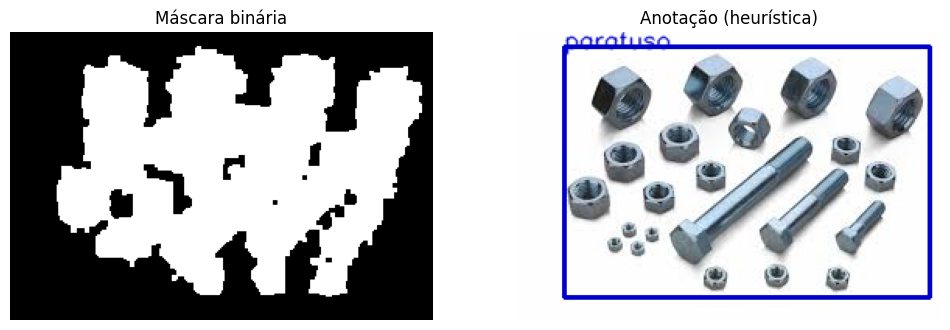

{
  "input_image": "data/images/sample_bolts_nuts.jpg",
  "vision_result": {
    "objetos": {
      "porca": 0,
      "parafuso": 1
    },
    "total": 1,
    "qualidade": "boa",
    "metrica": {
      "n_contornos": 1,
      "area_media": 24542.0
    }
  },
  "nlp_report": "A imagem contém 1 parafuso(s) e 0 porca(s), totalizando 1 item(ns). O lote aparenta estar consistente visualmente.",
  "decision": {
    "decision": "Aprovar",
    "reason": "Detecção consistente e contagens válidas.",
    "summary": "A imagem contém 1 parafuso(s) e 0 porca(s), totalizando 1 item(ns). O lote aparenta estar consistente visualmente."
  },
  "timestamp_utc": "2025-11-12T18:27:08.808336Z",
  "version": "mvp-0.1"
}

📁 Log salvo em: data/logs/ai_agent_hub_20251112T182708Z_48f45c0b.json


/tmp/ipython-input-442044024.py:16: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat() + "Z",
/tmp/ipython-input-3394962281.py:23: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")


In [14]:
def run_pipeline(img_bgr, image_path_hint="(buffer)"):
    vis, th_img, annotated = vision_agent_count(img_bgr)
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1); plt.title("Máscara binária"); plt.axis("off"); plt.imshow(th_img, cmap="gray")
    plt.subplot(1,2,2); plt.title("Anotação (heurística)"); plt.axis("off")
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.show()

    text = nlp_agent_describe(vis, idioma="pt")
    dec  = decision_agent(vis, text)
    report = {
        "input_image": image_path_hint,
        "vision_result": vis,
        "nlp_report": text,
        "decision": dec,
        "timestamp_utc": datetime.utcnow().isoformat() + "Z",
        "version": "mvp-0.1"
    }
    path = save_log(report, prefix="ai_agent_hub")
    print(json.dumps(report, ensure_ascii=False, indent=2))
    print(f"\n📁 Log salvo em: {path}")

# Executa com a imagem atual
run_pipeline(img_bgr, image_path_hint=image_path)
